### Exercise: Frequentist Coverage and Loss of Identifiability in NV Center ODMR

**The Physics Context:**
In quantum sensing, Nitrogen-Vacancy (NV) centers in diamond are read out using Optically Detected Magnetic Resonance (ODMR). You sweep a microwave frequency across the resonance and count the emitted photons. At the resonance frequency, the fluorescence drops, creating a "dip" in the spectrum.

To make the numerics manageable, our variable $\nu$ represents the **detuning** (in MHz) from the expected resonance (which is typically ~2.87 GHz). Therefore, a sweep from -5 to +5 means we are sweeping $\pm 5$ MHz around the center.

**The Statistical Model:**
Because we are counting independent photons, the number of observed photons $N_i$ at each discrete frequency point $\nu_i$ follows a Poisson distribution. The expected rate $\lambda(\nu_i)$ is modeled as a constant background $B$ minus a Lorentzian dip of amplitude $A$ (the contrast) and width $\gamma$:
$$\lambda(\nu_i) = B - A \frac{\gamma^2}{(\nu_i - \nu_0)^2 + \gamma^2}$$

The physical meaning and typical values of the parameters for our toy model are:
* **$B$ (Background):** Base photon counts per measurement point (True value = 1000).
* **$A$ (Amplitude/Contrast):** The depth of the dip in photon counts.
* **$\nu_0$ (Center):** The true resonance detuning (True value = 0.0 MHz).
* **$\gamma$ (Linewidth):** The width of the resonance (True value = 1.0 MHz).

**The Goal:**
If the true contrast $A$ is very weak, the signal gets buried in the Poisson noise ($\sqrt{B}$). In this regime, the linewidth $\gamma$ becomes completely unconstrained (a flat likelihood). This is called a "loss of identifiability." Your goal is to study how this affects the 2D Confidence Region of $(A, \gamma)$ and whether Wilks' theorem (which predicts $2\Delta\text{NLL}$ follows a $\chi^2$ distribution) holds at varying signal-to-noise ratios.

**Step-by-Step Instructions:**

1. **The Generative Model & Likelihood:** 
   * Write a Python function `rate_model(nu, B, A, nu0, gamma)` that returns the expected rate.
   * Write a function to generate toy datasets with Poisson fluctuations for the number of photons at 50 discrete points of the frequency detuning $\nu$ between -5 and 5.
   * Write a custom Negative Log-Likelihood (NLL) function for Poisson data.
2. **The Fitter:**
   * Set up an `iminuit.Minuit` object. Set sensible limits (e.g., $B>0, A>0, \gamma>0$).
3. **Checking 2D Coverage (The Core Loop):**
   * Write a function that runs $N_{toys} = 300$ pseudo-experiments for a given true value of $A$.
   * For each toy, perform a fit to find the MLE for the parameters.
   * Then calculate a 2D confidence interval at 68.3% level for the parameters of interest $A$ and $\gamma$.
   * Check if the 2D confidence interval includes the true value of $A$ and $\gamma$ and keep track of the coverage fraction.
4. **Visualizing Wilks' Theorem:**
   * We use a test statistic $t$ based on the profiled likelihood ratio to get the 2D confidence interval of the POIs $A$ and $\gamma$.
   * Plot a histogram of your $t$ values. Overlay the theoretical PDF predicted by Wilks' theorem.
5. **Scanning the Contrast:**
   * Run your loop for three scenarios: a "Strong Signal" ($A=500$), a "Weak Signal" ($A=100$), and a "Very Weak Signal" ($A=20$).
   * Visualize the 2D profile likelihood contours for these three cases. What happens to the contour when the signal is very weak?
   * Compare the coverage fractions and the shapes of the test statistic histograms across the three scenarios.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from iminuit import Minuit
from scipy.stats import poisson
import matplotlib.pyplot as plt

# ==========================================
# GENERATIVE MODEL & LIKELIHOOD
# ==========================================

def rate_model(nu, B, A, nu0, gamma):
    """Lorentzian dip on a constant background."""
    return B - A * (gamma**2 / ((nu - nu0)**2 + gamma**2))

def generate_toy(nu, B, A, nu0, gamma):
    """Generates a toy dataset with Poisson fluctuations."""
    expected_rate = rate_model(nu, B, A, nu0, gamma)
    # Ensure physical rates (no negative expected photons)
    expected_rate = np.maximum(expected_rate, 1e-6)
    return np.random.poisson(expected_rate)

def create_nll(nu_data, N_data):
    # nu_data = x, N_data = y
    """Creates a custom Poisson NLL function bound to specific data."""
    """ I calculate the theorical number of points in the dataset at that point using the model and then I evaluate the probability using the poisson distribution in it"""
    def nll(B, A, nu0, gamma):
        lam = rate_model(nu_data, B, A, nu0, gamma)
        lam = np.maximum(lam, 1e-12) # Protect against log(0) or negative rates

        # Calculate the negative log-likelihood using scipy
        return -np.sum(poisson.logpmf(N_data, mu=lam))

    return nll


Text(0, 0.5, 'Photon Counts')

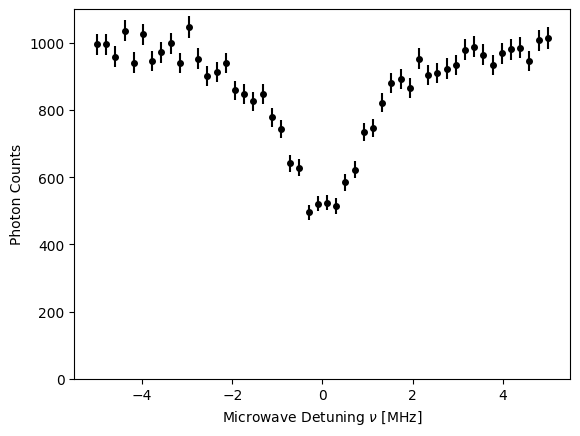

In [2]:
nu_sweep = np.linspace(-5, 5, 50)
B_true, nu0_true, gamma_true = 1000.0, 0.0, 1.0

N_strong = generate_toy(nu_sweep, B_true, A=500, nu0=nu0_true, gamma=gamma_true)
plt.errorbar(nu_sweep, N_strong, yerr=np.sqrt(N_strong), fmt='ko', markersize=4, label='Toy Data')
plt.ylim(0, 1100)
plt.xlabel("Microwave Detuning $\\nu$ [MHz]")
plt.ylabel("Photon Counts")

In [10]:
nu_sweep = np.linspace( -5 , 5 )

Ns = generate_toy( nu_sweep , B_true , 500 , nu0_true , gamma_true)
Nm = generate_toy( nu_sweep , B_true , 300 , nu0_true , gamma_true)
Nw = generate_toy( nu_sweep , B_true , 100 , nu0_true , gamma_true)
Nsw = generate_toy( nu_sweep , B_true , 20 , nu0_true , gamma_true)

nll_s = create_nll(nu_sweep , Ns)
Ms = Minuit( nll_s , B = B_true, A = 500 , nu0 = 0 , gamma = 1)
Ms.migrad()

nll_m = create_nll(nu_sweep , Nm)
Mm = Minuit( nll_m , B = B_true, A = 300 , nu0 = 0 , gamma = 1)
Mm.migrad()


nll_w = create_nll(nu_sweep , Nw)
Mw = Minuit( nll_w , B = B_true, A = 100 , nu0 = 0 , gamma = 1)
Mw.migrad();

In [28]:
def likelihood_constructor( x: np.ndarray, y: np.ndarray):
    def likelihood( B , A , nu0, gamma):
        y_expected = rate_model( x , B , A , nu0 , gamma)
        #  for each y, i calculate the probability of it being there
        prob = poisson.pmf( y , mu = y_expected)
        return np.prod(prob)

def nll( x: np.ndarray, y: np.ndarray):
    def likelihood( B , A , nu0, gamma):
        y_expected = rate_model( x , B , A , nu0 , gamma)
        y_expected = np.maximum(y_expected, 1e-12)

        #  for each y, i calculate the probability of it being there
        logprob = np.array([poisson.logpmf( y[i] , mu = y_expected[i]) for i in range(len(y))])
        return -np.sum(logprob)
    return likelihood


def toy_experiment( B, A , nu0 , gamma, nu_range: np.ndarray):
    expected_measurement: np.ndarray = rate_model( nu_range , B , A , nu0 , gamma)
    dataset = poisson.rvs( mu = expected_measurement)
    return dataset

def simulation_loop( B, A , nu0 , gamma, nu_range, N_toys: int):
    parameters_dict = {
        "B": [],
        "A": [],
        "nu0": [],
        "gamma": [],
    }
    for _ in range(N_toys):
        dataset = toy_experiment( B, A , nu0 , gamma, nu_range)
        nll_toy = nll( nu_range , dataset)
        m_toy = Minuit( nll_toy , B , A , nu0, gamma)
        m_toy.migrad()
        if m_toy.valid:
            parameters_dict["B"].append(m_toy.values["B"])
            parameters_dict["A"].append(m_toy.values["A"])
            parameters_dict["nu0"].append(m_toy.values["nu0"])
            parameters_dict["gamma"].append(m_toy.values["gamma"])
        else: print( "failed interpolation")
    return parameters_dict


In [29]:
strong_dict = simulation_loop( B_true , 500 , nu0_true , gamma_true, np.arange(-5 , 5) , 300)
mid_dict = simulation_loop( B_true , 300 , nu0_true , gamma_true, np.arange(-5 , 5) , 300)
weak_dict = simulation_loop( B_true , 100 , nu0_true , gamma_true, np.arange(-5 , 5) , 300)

failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation
failed interpolation


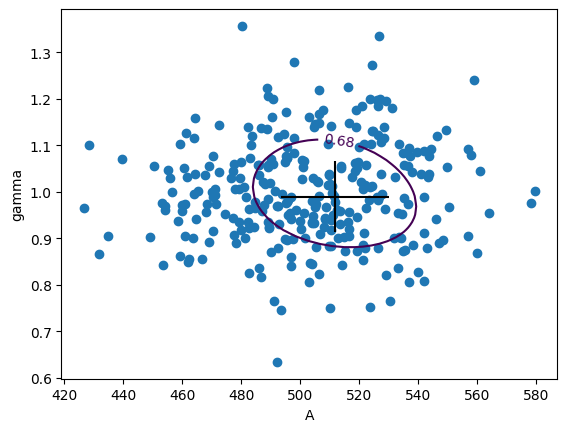

In [35]:
def plot_contour( dict , var1 , var2): 
    plt.scatter( dict[var1] , dict[var2])


plot_contour( strong_dict , "A" , "gamma")
plt.errorbar( Ms.values["A"], Ms.values["gamma"] , Ms.errors["gamma"] , Ms.errors["A"] , color = "black")
Ms.draw_mncontour("A" , "gamma")